# License Plate Detection using Haar Cascade

**Student Name:** Joel John Jobinse  
**Register Number:** 212223240062 

---


In [1]:
# 1. Import required libraries

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("OpenCV version:", cv2.__version__)


OpenCV version: 5.0.0


## 2. Locate the input image and Haar Cascade

The assignment requires the Haar Cascade XML file to be linked correctly. The code first looks for the XML file beside this notebook. If it is not present, it uses the same cascade bundled with OpenCV, which keeps the notebook runnable.


In [2]:
# Find the input image
image_candidates = [
    Path("car_plate.jpg"),
    Path("/mnt/data/car_plate.jpg")
]

image_path = next((p for p in image_candidates if p.exists()), None)

if image_path is None:
    raise FileNotFoundError(
        "car_plate.jpg was not found. Place car_plate.jpg in the same folder as this notebook."
    )

# Find the Haar Cascade XML
cascade_candidates = [
    Path("haarcascade_russian_plate_number.xml"),
    Path(cv2.data.haarcascades) / "haarcascade_russian_plate_number.xml"
]

cascade_path = next((p for p in cascade_candidates if p.exists()), None)

if cascade_path is None:
    raise FileNotFoundError(
        "haarcascade_russian_plate_number.xml was not found. "
        "Place it in the notebook folder."
    )

print("Image:", image_path.resolve())
print("Cascade:", cascade_path.resolve())


Image: C:\Users\admin\Downloads\License_Plate_Detection_Submission_Joel_John_Jobinse\license_plate_submission\car_plate.jpg
Cascade: C:\Users\admin\Downloads\License_Plate_Detection_Submission_Joel_John_Jobinse\license_plate_submission\haarcascade_russian_plate_number.xml


## 3. Read and display the input image

OpenCV reads images in **BGR** format, while Matplotlib expects **RGB**. Therefore, the display function converts the image before plotting it.


Image shape: (358, 634, 3)


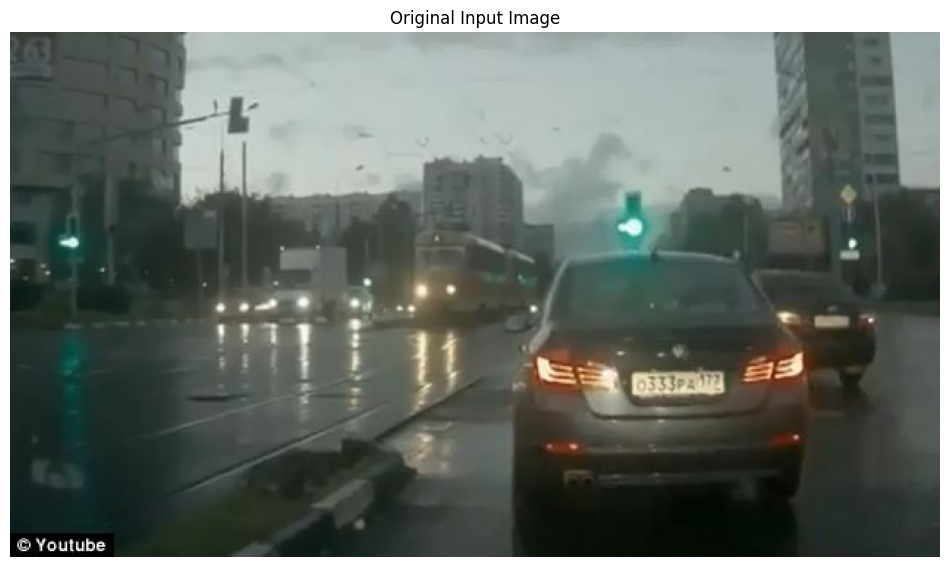

In [3]:
# Read image
img = cv2.imread(str(image_path))

if img is None:
    raise ValueError("The image could not be read. Check the image path.")

def display_image(image, title="", figsize=(12, 7)):
    """Display an OpenCV BGR image correctly using Matplotlib."""
    plt.figure(figsize=figsize)
    if len(image.shape) == 2:
        plt.imshow(image, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

print("Image shape:", img.shape)
display_image(img, "Original Input Image")


## 4. Convert the image to grayscale

Haar Cascade detection works on a single-channel grayscale image. Converting to grayscale reduces computational complexity while retaining the intensity information needed by the classifier.


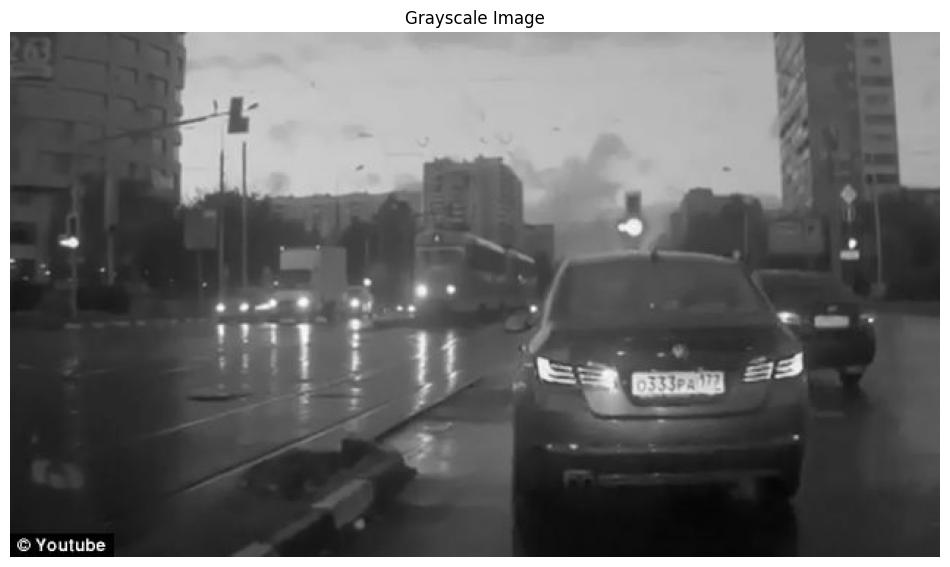

In [4]:
# Convert BGR image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

display_image(gray, "Grayscale Image")


## 5. Improvement: image preprocessing

As the required improvement, CLAHE (Contrast Limited Adaptive Histogram Equalization) is applied to improve local contrast, followed by a small Gaussian blur to reduce noise.

This preprocessing is used only for the improved detection path. It can make the detector more robust when the image has uneven illumination or mild noise.


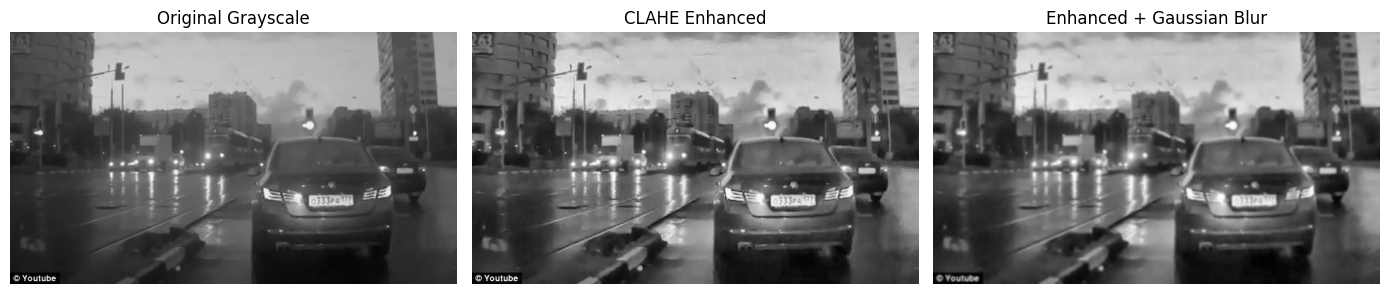

In [5]:
# Improved preprocessing
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced_gray = clahe.apply(gray)

# Small Gaussian blur to reduce high-frequency noise
preprocessed_gray = cv2.GaussianBlur(enhanced_gray, (5, 5), 0)

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(enhanced_gray, cmap="gray")
plt.title("CLAHE Enhanced")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(preprocessed_gray, cmap="gray")
plt.title("Enhanced + Gaussian Blur")
plt.axis("off")

plt.tight_layout()
plt.show()


## 6. Load the Haar Cascade classifier

`CascadeClassifier` loads the pre-trained XML model. The classifier contains Haar-like features trained to locate license-plate patterns.


In [6]:
plate_cascade = cv2.CascadeClassifier(str(cascade_path))

if plate_cascade.empty():
    raise ValueError("The Haar Cascade XML could not be loaded correctly.")

print("Haar Cascade loaded successfully.")


Haar Cascade loaded successfully.


## 7. License plate detection

The main parameters are:

- `scaleFactor=1.1`: the image is reduced by about 10% at each scale during the multi-scale search.
- `minNeighbors=5`: controls how many neighboring detections are required before a candidate is accepted; increasing it generally reduces false positives.
- `minSize=(30, 10)`: ignores very small candidate regions.

The function returns the image with bounding boxes and the detected plate crops.


In [7]:
def detect_plates(image_bgr, detection_gray, scale_factor=1.1, min_neighbors=5):
    """Detect license plates and return annotated image, rectangles, and crops."""

    rectangles = plate_cascade.detectMultiScale(
        detection_gray,
        scaleFactor=scale_factor,
        minNeighbors=min_neighbors,
        minSize=(30, 10)
    )

    annotated = image_bgr.copy()
    crops = []

    for i, (x, y, w, h) in enumerate(rectangles, start=1):
        # Draw bounding box
        cv2.rectangle(
            annotated,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

        # Add label
        cv2.putText(
            annotated,
            f"Plate {i}",
            (x, max(y - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

        # Crop detected plate
        crop = image_bgr[y:y+h, x:x+w].copy()
        crops.append(crop)

    return annotated, rectangles, crops


## 8. Basic detection on grayscale image

This is the standard Haar Cascade pipeline: grayscale image → `detectMultiScale()` → bounding boxes.


Basic detection count: 1
Detected rectangles: [[418 226  76  25]]


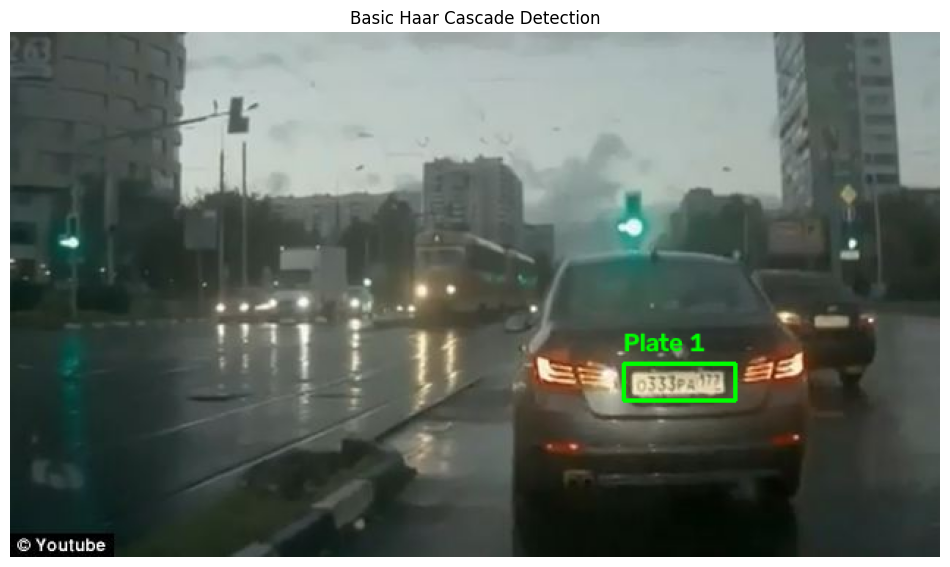

In [8]:
basic_result, basic_rectangles, basic_crops = detect_plates(
    img,
    gray,
    scale_factor=1.1,
    min_neighbors=5
)

print("Basic detection count:", len(basic_rectangles))
print("Detected rectangles:", basic_rectangles)

display_image(basic_result, "Basic Haar Cascade Detection")


## 9. Improved detection using preprocessing

The improved version uses the CLAHE + Gaussian-blur image as the input to the same Haar Cascade. This satisfies the improvement requirement without changing the underlying classifier.


Improved detection count: 1
Detected rectangles: [[417 226  76  25]]


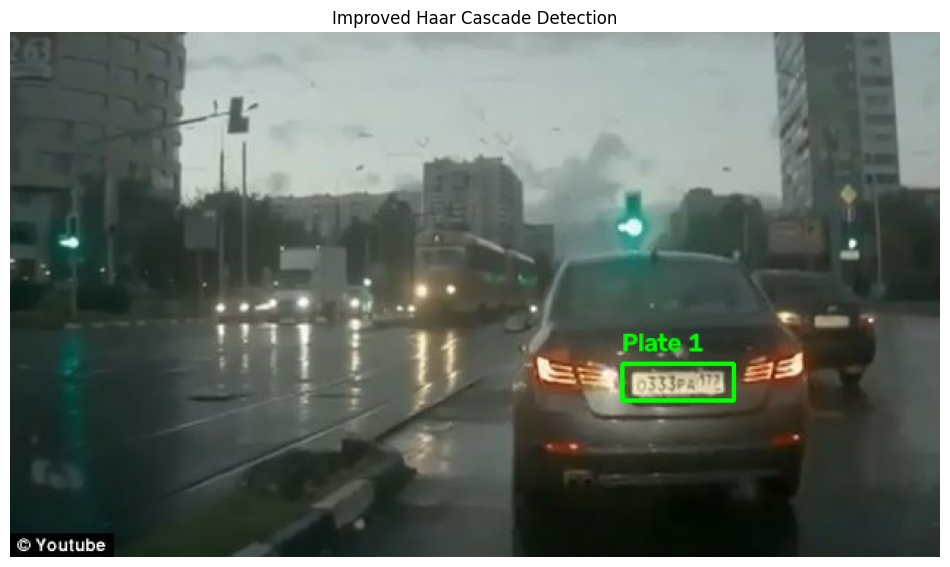

In [9]:
improved_result, improved_rectangles, improved_crops = detect_plates(
    img,
    preprocessed_gray,
    scale_factor=1.1,
    min_neighbors=5
)

print("Improved detection count:", len(improved_rectangles))
print("Detected rectangles:", improved_rectangles)

display_image(improved_result, "Improved Haar Cascade Detection")


## 10. Compare detection results

The comparison below makes the effect of the preprocessing step easy to observe.


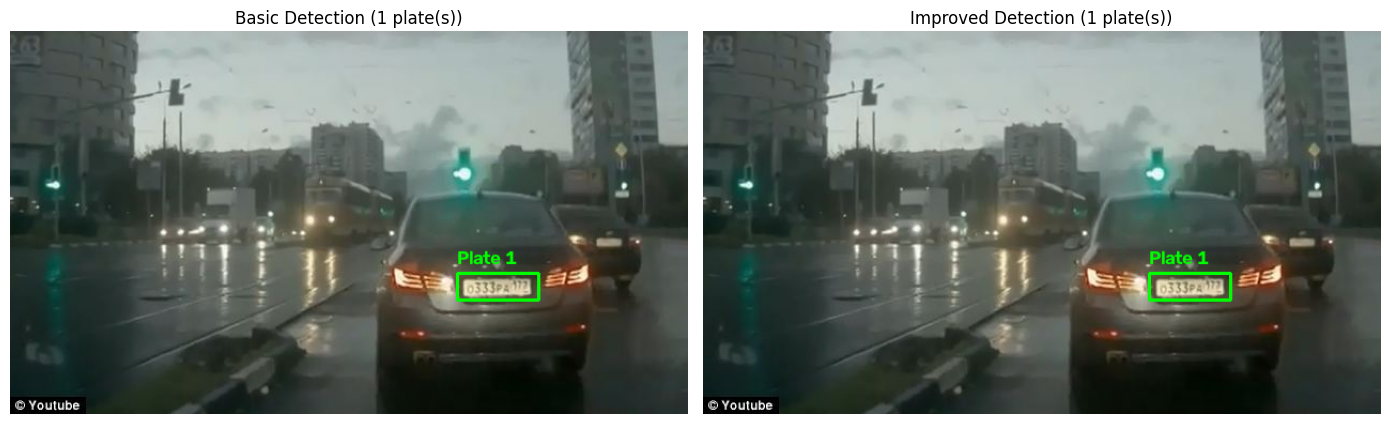

In [10]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(basic_result, cv2.COLOR_BGR2RGB))
plt.title(f"Basic Detection ({len(basic_rectangles)} plate(s))")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(improved_result, cv2.COLOR_BGR2RGB))
plt.title(f"Improved Detection ({len(improved_rectangles)} plate(s))")
plt.axis("off")

plt.tight_layout()
plt.show()


## 11. Crop and save the detected license plate

The `(x, y, w, h)` values returned by the classifier are used to extract the region of interest:

`image[y:y+h, x:x+w]`

The largest detected region is selected as the final plate candidate and saved as `detected_plate.png`.


Detected plate saved to: C:\Users\admin\Downloads\License_Plate_Detection_Submission_Joel_John_Jobinse\license_plate_submission\outputs\detected_plate.png


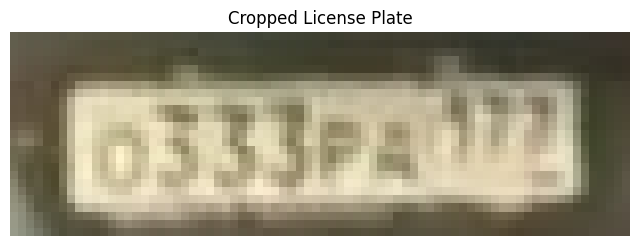

In [11]:
# Prefer the improved detections; fall back to basic detections if needed
final_rectangles = improved_rectangles if len(improved_rectangles) > 0 else basic_rectangles
final_crops = improved_crops if len(improved_crops) > 0 else basic_crops

if len(final_crops) == 0:
    print("No license plate was detected. Try lowering minNeighbors or adjusting scaleFactor.")
else:
    # Select the largest detected region
    best_index = int(np.argmax([w * h for (x, y, w, h) in final_rectangles]))
    detected_plate = final_crops[best_index]

    output_dir = Path("outputs")
    output_dir.mkdir(exist_ok=True)

    output_path = output_dir / "detected_plate.png"
    cv2.imwrite(str(output_path), detected_plate)

    print("Detected plate saved to:", output_path.resolve())
    display_image(detected_plate, "Cropped License Plate", figsize=(8, 3))


## 12. Parameter experimentation

`scaleFactor` and `minNeighbors` affect detection behavior. A smaller `scaleFactor` searches more scales and can improve sensitivity, but it increases computation. A larger `minNeighbors` is stricter and can reduce false positives.

The following small experiment prints the detections obtained with several parameter combinations.


In [12]:
# Small parameter experiment
parameter_sets = [
    (1.05, 3),
    (1.10, 5),
    (1.20, 5),
    (1.30, 5),
]

print("scaleFactor | minNeighbors | detections")
print("----------------------------------------")

for scale_factor, min_neighbors in parameter_sets:
    rects = plate_cascade.detectMultiScale(
        preprocessed_gray,
        scaleFactor=scale_factor,
        minNeighbors=min_neighbors,
        minSize=(30, 10)
    )
    print(f"{scale_factor:10.2f} | {min_neighbors:12d} | {len(rects)}")


scaleFactor | minNeighbors | detections
----------------------------------------
      1.05 |            3 | 1
      1.10 |            5 | 1
      1.20 |            5 | 1
      1.30 |            5 | 0


      1.05 |            3 | 1
      1.10 |            5 | 1
      1.20 |            5 | 1
      1.30 |            5 | 0


## 13. Conclusion

The notebook successfully implements license plate detection using a pre-trained Haar Cascade. The pipeline reads the input image, converts it to grayscale, optionally improves the image using CLAHE and Gaussian blur, detects the plate with `detectMultiScale()`, draws a bounding box, and crops/saves the detected plate.

### Key observation
Haar Cascade detection is lightweight and easy to implement, but its accuracy depends strongly on image conditions and parameter settings. The preprocessing step is useful for improving the input image before detection, while `scaleFactor` and `minNeighbors` control the sensitivity and strictness of the detector.
